In [1]:
import logging
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from lightning import seed_everything
from sklearn.decomposition import NMF
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from explainability.cams import grad_cam, grad_cam_pp
from explainability.cams.abstract import (
    HookedModule,
    modify_ReLU_inplace,
    reshape_for_clustering,
)
from explainability.precomputing import ClusteringManager
from prostate_cancer.data import DataModule
from prostate_cancer.prostate_cancer_model import ProstateCancerModel

In [2]:
def get_clustering_instance_fp(clustering_algorithm: str, num_clusters: int) -> Path:
    return Path(
        "/mnt/projects/explainability/XAICNNEmbeddings/PRECOMPUTED",
        "VGG16_Prostate",
        "global_clustering_instances",
        f"clustering_instance_test_global_{clustering_algorithm.lower()}_{num_clusters}clusters.npy",
    )

In [3]:
clustering_algorithm = "NMF"
NUM_CLUSTERS = 6

In [6]:
clustering_instance_fp = get_clustering_instance_fp(clustering_algorithm, NUM_CLUSTERS)

clustering_model: NMF = ClusteringManager.load_model(
    algorithm=clustering_algorithm,
    num_clusters=NUM_CLUSTERS,
    path=clustering_instance_fp,
)

OSError: [Errno 116] Stale file handle: '/mnt/projects/explainability/XAICNNEmbeddings/PRECOMPUTED/VGG16_Prostate/global_clustering_instances/clustering_instance_test_global_nmf_6clusters.npy'

In [ ]:
logging.basicConfig(level=logging.INFO)

# Set random seed for reproducibility
seed_everything(42, workers=True)
torch.set_float32_matmul_precision(precision="medium")

# Configuration overrides for prediction
overrides = ["experiment=predict/images/vgg16", "mode=predict"]

# Initialize Hydra configuration
with hydra.initialize(config_path="conf", version_base=None):
    config = hydra.compose(config_name="default", overrides=overrides)

print("Configuration loaded successfully!")
print(f"Mode: {config.mode}")
print(f"Checkpoint: {config.checkpoint}")
print(f"Batch size: {config.data.batch_size}")

# Instantiate data module and model
data: DataModule = hydra.utils.instantiate(
    config.data,
    _recursive_=False,  # to avoid instantiating all the datasets
    _target_=DataModule,
)

chkcpt_path = mlflow.artifacts.download_artifacts(config.checkpoint)
model: ProstateCancerModel = hydra.utils.instantiate(config.model)
checkpoint = torch.load(chkcpt_path, map_location="cuda:0")
model.load_state_dict(checkpoint["state_dict"], strict=True)

model = model.to("cuda:0")

print("Data module and model instantiated successfully!")

print(model)

Seed set to 42


Configuration loaded successfully!
Mode: predict
Checkpoint: mlflow-artifacts:/65/7b52930515c14710855962f8882fb4d3/artifacts/checkpoints/epoch=1-step=11620/checkpoint.ckpt
Batch size: 74


Data module and model instantiated successfully!
ProstateCancerModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
 

In [ ]:
target_layer = "backbone.29"
hooked_model = HookedModule(model, layer_names=[target_layer])
modify_ReLU_inplace(hooked_model, inplace=False)

In [ ]:
# Get one batch from validation dataset
data.batch_size = 32
data.setup("test")
dataloaders = data.test_dataloader()
print(len(dataloaders))

87


In [ ]:
def create_data(n, seed=42):
    # Set seed for reproducibility
    np.random.seed(seed)
    # Also set Python's random seed if needed
    import random

    random.seed(seed)
    # Set torch seed as well for complete reproducibility
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Set scikit-learn random state (uses numpy's random state, but explicit is better)
    # Note: sklearn functions that accept random_state parameter should use this seed

    num_slides = len(dataloaders)
    slide_indices = np.random.choice(range(num_slides), n, replace=True)

    slide_counts = [0] * num_slides

    for slide_index in slide_indices:
        slide_counts[slide_index] += 1

    header = (
        ["label", "output"]
        + [f"weight_sum_{i}" for i in range(NUM_CLUSTERS)]
        + [f"cluster_count_{i}" for i in range(NUM_CLUSTERS)]
        + [f"cluster_soft_count_{i}" for i in range(NUM_CLUSTERS)]
    )

    for cam in ["grad_cam_pp", "grad_cam"]:
        header += [f"{cam}_count"]
        for i in range(NUM_CLUSTERS):
            header += [f"intersection_count_{cam}_{i}", f"union_count_{cam}_{i}"]
            header += [
                f"intersection_soft_count_{cam}_{i}",
                f"union_soft_count_{cam}_{i}",
            ]
            header += [f"correlation_{cam}_{i}"]

    data = []

    for slide_index, count in enumerate(slide_counts):
        if count == 0:
            continue

        dataloader = dataloaders[slide_index]
        dataset = dataloader.dataset
        num_tiles_in_slide = len(dataset)

        tile_indices = np.random.choice(num_tiles_in_slide, count, replace=True)

        for tile_idx in tile_indices:
            tile, label, metadata = dataset[tile_idx]
            tile = tile.to("cuda:0").unsqueeze(0)

            output = hooked_model(tile)
            output.backward()

            tile_data = [label.item(), output.cpu().item()]

            activations = hooked_model.get_activations(target_layer)
            activations_flattened, shape = reshape_for_clustering(activations)
            activations_np = activations_flattened.detach().cpu().numpy()

            weights = clustering_model.transform(activations_np)
            weights_sum = np.sum(weights, axis=0)

            tile_data.extend(weights_sum.tolist())

            batch_size, _, height, width = shape
            weights_reshaped = weights.reshape(batch_size, height, width, NUM_CLUSTERS)

            clustering = weights.argmax(axis=1)

            clustering = clustering.reshape(batch_size, height, width)

            # count number of tiles per cluster
            cluster_counts = np.bincount(clustering.flatten())

            tile_data.extend(cluster_counts.tolist())

            for i in range(NUM_CLUSTERS):
                tile_data.append((weights[:, i] > 1e-9).sum())

            # for each cluster, create a binary mask
            masks = []

            for i in range(weights_sum.shape[0]):
                # Create mask with spatial dimensions (H, W)
                mask = np.zeros((height, width), dtype=np.float32)
                # Create mask where activations for cluster i are positive
                mask[clustering[0, :, :] == i] = 1

                assert mask.sum() == cluster_counts[i]
                assert mask.shape == (height, width)

                masks.append(mask)

            soft_masks = []

            for i in range(NUM_CLUSTERS):
                # soft mask is where weight is positive
                mask = np.zeros((height, width), dtype=np.float32)
                # Use [0, :, :, i] to get the first batch element with shape (H, W)
                mask[weights_reshaped[0, :, :, i] > 1e-9] = 1

                assert mask.shape == (height, width)

                soft_masks.append(mask)

            gradients = hooked_model.get_gradients(target_layer)

            for cam_fn in [grad_cam_pp, grad_cam]:
                cam = cam_fn(activations, gradients)
                cam_np = cam.flatten().detach().cpu().numpy()
                cam_mask = (cam > 1e-9).detach().cpu().numpy()
                cam_count = cam_mask.sum()

                tile_data.append(cam_count)

                for i in range(NUM_CLUSTERS):
                    for cluster_mask in [masks[i], soft_masks[i]]:
                        # count intersection of cam_mask and cluster_mask
                        intersection_count = (cam_mask * cluster_mask).sum()

                        # count union of cam_mask and cluster_mask
                        union_count = (cam_mask + cluster_mask).sum()

                        tile_data.extend([int(intersection_count), int(union_count)])

                    # compute correlation between cam and weights for cluster i
                    # Use [0, :, :, i] to get the first batch element with shape (H, W)
                    weights_cluster = weights_reshaped[0, :, :, i].flatten()

                    # Handle correlation when CAM is all zeros (will cause NaN)
                    if (
                        cam_count == 0
                        or np.std(cam_np) == 0
                        or np.std(weights_cluster) == 0
                    ):
                        correlation = np.nan
                    else:
                        correlation = np.corrcoef(cam_np, weights_cluster)[0, 1]
                    tile_data.append(correlation)

            hooked_model.zero_grad()

            assert len(tile_data) == len(header)

            data.append(tile_data)

    data = pd.DataFrame(data, columns=header)
    return data

In [ ]:
# data_2 = create_data(n=1000, seed=42)
# data_2.to_csv("data_2.csv", index=False)

In [ ]:
# load data from data.csv
data = pd.read_csv("data_2.csv")

label
0.0    838
1.0    162
Name: count, dtype: int64

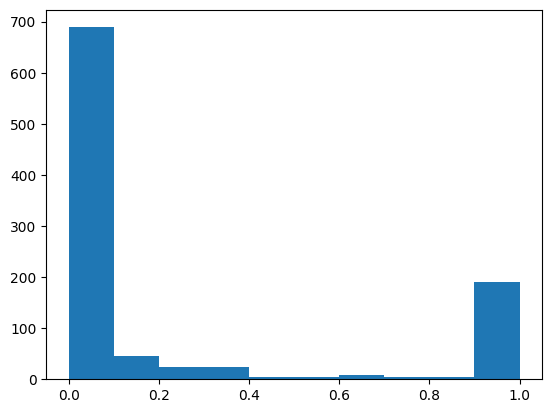

In [ ]:
# y is the sigmoid of output
data["y"] = 1 / (1 + np.exp(-data["output"]))

# print count of labels - either 0 or 1
display(data["label"].value_counts())
plt.hist(data["y"])
plt.show()

In [ ]:
data["predicted_label"] = (data["y"] > 0.94).astype(int)
# print matrix of predicted_label vs label
display(pd.crosstab(data["predicted_label"], data["label"]))
# metrics
print(f"Accuracy: {accuracy_score(data['label'], data['predicted_label'])}")
print(f"Precision: {precision_score(data['label'], data['predicted_label'])}")
print(f"Recall: {recall_score(data['label'], data['predicted_label'])}")
print(f"F1 Score: {f1_score(data['label'], data['predicted_label'])}")

print(f"AUC Score: {roc_auc_score(data['label'], data['y'])}")

label,0.0,1.0
predicted_label,,
0,809,5
1,29,157


Accuracy: 0.966
Precision: 0.8440860215053764
Recall: 0.9691358024691358
F1 Score: 0.9022988505747126
AUC Score: 0.991897227378532


In [ ]:
# Add IoU columns for each method and cluster
for method in ["grad_cam_pp", "grad_cam"]:
    for i in range(NUM_CLUSTERS):
        intersection_col = f"intersection_count_{method}_{i}"
        union_col = f"union_count_{method}_{i}"
        iou_col = f"iou_{method}_{i}"

        # Avoid division by zero; if union is zero, set IoU to np.nan
        data[iou_col] = np.where(
            data[union_col] > 0, data[intersection_col] / data[union_col], np.nan
        )

In [ ]:
# fit a linear regression model to the data, tthat predicts y from weights_sum_0, weights_sum_1, ..., weights_sum_5


X = data[[f"weight_sum_{i}" for i in range(NUM_CLUSTERS)]]
y = data["output"]

model = LinearRegression()
# fit using mean squared error
model.fit(X, y)

# print the coefficients
print(model.coef_)
print(model.intercept_)

# print standard metrics
print(f"R-squared: {model.score(X, y)}")

[-0.03400695  0.01056245 -0.04100761  0.27662103  0.30653419 -0.12563195]
-1.198089616947946
R-squared: 0.8578462091726865


In [ ]:
X_clusters = data[[f"cluster_count_{i}" for i in range(NUM_CLUSTERS)]]

model_clusters = LinearRegression()
# fit using mean squared error
model_clusters.fit(X_clusters, y)

# print the coefficients
print(model_clusters.coef_)
print(model_clusters.intercept_)

# print standard metrics
print(f"R-squared: {model_clusters.score(X_clusters, y)}")

[-0.01340487  0.01298909 -0.01510032  0.03909689 -0.00513638 -0.01844441]
8.932662976443225
R-squared: 0.7805082643937312


In [ ]:
# filter for grad_cam_pp soft IoU columns
iou_cols = [f"iou_grad_cam_pp_{i}" for i in range(NUM_CLUSTERS)]

# Create two figures: one for label 0, one for label 1
for label_value in [0, 1]:
    plt.figure(figsize=(12, 6))

    # Collect data for all clusters for this label
    cluster_data = []
    cluster_labels = []

    for i, iou_col in enumerate(iou_cols):
        # Get IoU values directly
        iou_data = data[data["predicted_label"] == label_value][iou_col].dropna()
        cluster_data.append(iou_data)
        cluster_labels.append(f"Cluster {i}")

    # Create boxplot with all clusters side by side
    plt.boxplot(cluster_data, tick_labels=cluster_labels)
    plt.title(
        f"Boxplot of Grad-CAM++ Soft IoU by Cluster for Predicted Label {label_value}"
    )
    plt.xlabel("Cluster")
    plt.ylabel("Soft IoU")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Create a figure with both labels together
plt.figure(figsize=(14, 6))

# Collect data for all clusters for both labels
cluster_data_label0 = []
cluster_data_label1 = []
cluster_labels = []

for i, iou_col in enumerate(iou_cols):
    # Get data for label 0
    iou_data_0 = data[data["predicted_label"] == 0][iou_col].dropna()
    cluster_data_label0.append(iou_data_0)

    # Get data for label 1
    iou_data_1 = data[data["predicted_label"] == 1][iou_col].dropna()
    cluster_data_label1.append(iou_data_1)

    cluster_labels.append(f"Cluster {i}")

# Create positions for grouped boxplots
positions = np.arange(len(cluster_labels))
width = 0.35

# Create boxplots for both labels
bp0 = plt.boxplot(
    cluster_data_label0,
    positions=positions - width / 2,
    widths=width,
    tick_labels=cluster_labels,
    patch_artist=True,
)
bp1 = plt.boxplot(
    cluster_data_label1,
    positions=positions + width / 2,
    widths=width,
    patch_artist=True,
)

# Color the boxes differently
for patch in bp0["boxes"]:
    patch.set_facecolor("lightblue")
for patch in bp1["boxes"]:
    patch.set_facecolor("lightcoral")

plt.title("Boxplot of Grad-CAM++ IoU by Cluster for Both Predicted Labels")
plt.xlabel("Cluster")
plt.ylabel("Soft IoU")
plt.xticks(positions, cluster_labels, rotation=45)
plt.legend([bp0["boxes"][0], bp1["boxes"][0]], ["Label 0", "Label 1"])
plt.tight_layout()
plt.show()

In [ ]:
# Add soft IoU columns for each method and cluster
for method in ["grad_cam_pp", "grad_cam"]:
    for i in range(NUM_CLUSTERS):
        intersection_col = f"intersection_soft_count_{method}_{i}"
        union_col = f"union_soft_count_{method}_{i}"
        iou_col = f"iou_soft_{method}_{i}"

        # Avoid division by zero; if union is zero, set IoU to np.nan
        data[iou_col] = np.where(
            data[union_col] > 0, data[intersection_col] / data[union_col], np.nan
        )

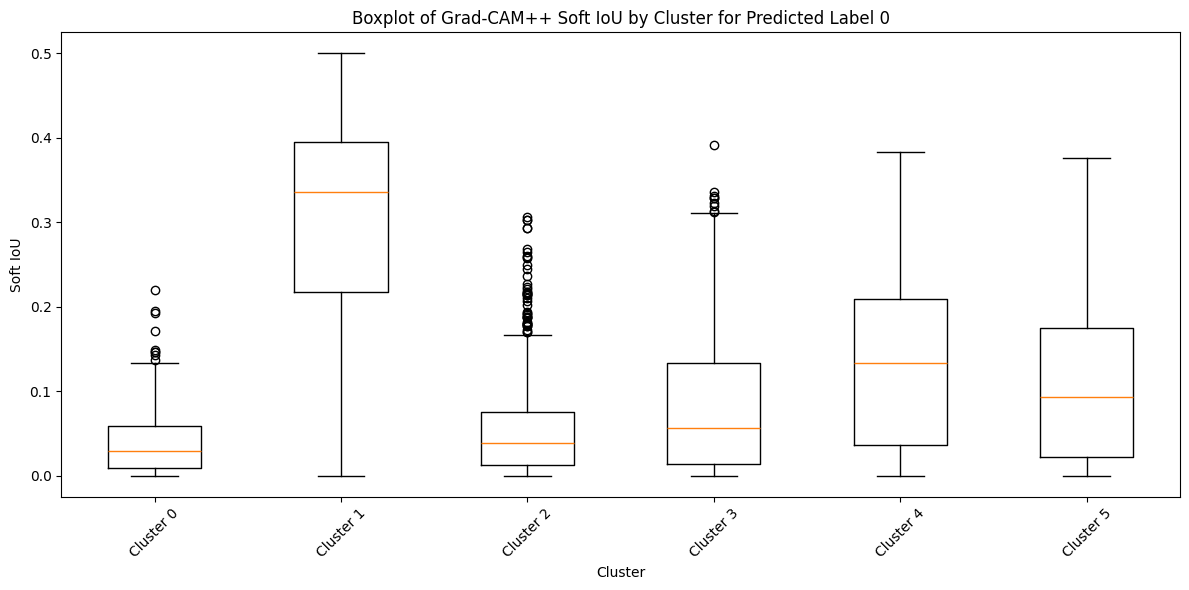

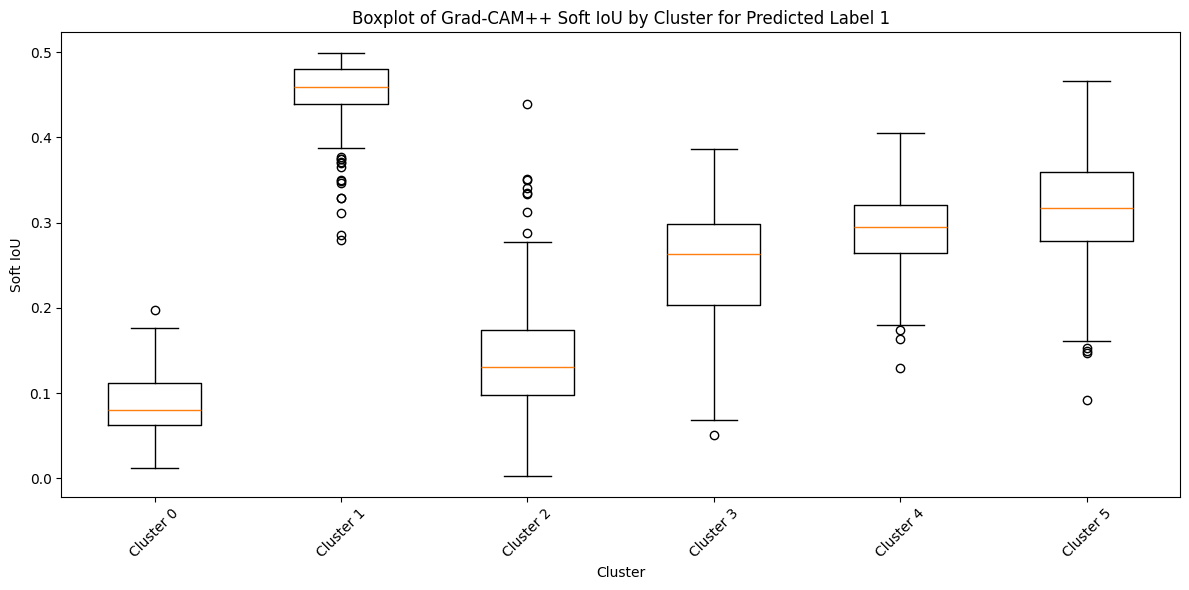

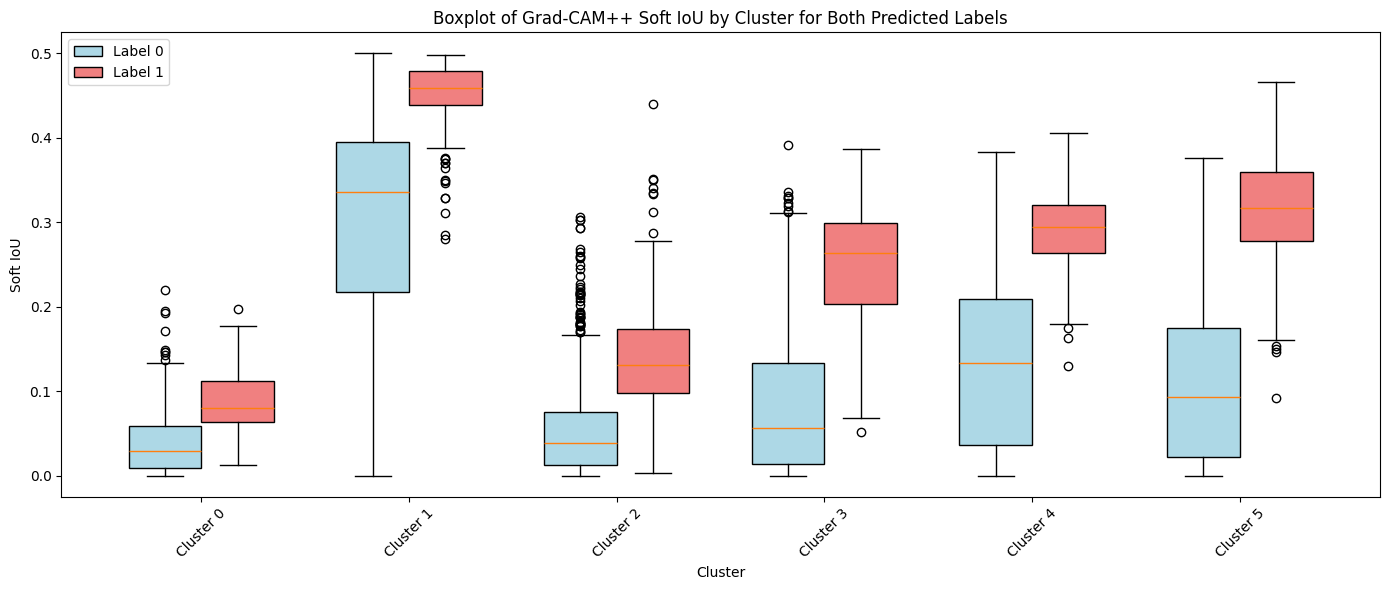

In [ ]:
# filter for grad_cam_pp soft IoU columns
iou_cols = [f"iou_soft_grad_cam_pp_{i}" for i in range(NUM_CLUSTERS)]

# Create two figures: one for label 0, one for label 1
for label_value in [0, 1]:
    plt.figure(figsize=(12, 6))

    # Collect data for all clusters for this label
    cluster_data = []
    cluster_labels = []

    for i, iou_col in enumerate(iou_cols):
        # Get IoU values directly
        iou_data = data[data["predicted_label"] == label_value][iou_col].dropna()
        cluster_data.append(iou_data)
        cluster_labels.append(f"Cluster {i}")

    # Create boxplot with all clusters side by side
    plt.boxplot(cluster_data, tick_labels=cluster_labels)
    plt.title(
        f"Boxplot of Grad-CAM++ Soft IoU by Cluster for Predicted Label {label_value}"
    )
    plt.xlabel("Cluster")
    plt.ylabel("Soft IoU")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Create a figure with both labels together
plt.figure(figsize=(14, 6))

# Collect data for all clusters for both labels
cluster_data_label0 = []
cluster_data_label1 = []
cluster_labels = []

for i, iou_col in enumerate(iou_cols):
    # Get data for label 0
    iou_data_0 = data[data["predicted_label"] == 0][iou_col].dropna()
    cluster_data_label0.append(iou_data_0)

    # Get data for label 1
    iou_data_1 = data[data["predicted_label"] == 1][iou_col].dropna()
    cluster_data_label1.append(iou_data_1)

    cluster_labels.append(f"Cluster {i}")

# Create positions for grouped boxplots
positions = np.arange(len(cluster_labels))
width = 0.35

# Create boxplots for both labels
bp0 = plt.boxplot(
    cluster_data_label0,
    positions=positions - width / 2,
    widths=width,
    tick_labels=cluster_labels,
    patch_artist=True,
)
bp1 = plt.boxplot(
    cluster_data_label1,
    positions=positions + width / 2,
    widths=width,
    patch_artist=True,
)

# Color the boxes differently
for patch in bp0["boxes"]:
    patch.set_facecolor("lightblue")
for patch in bp1["boxes"]:
    patch.set_facecolor("lightcoral")

plt.title("Boxplot of Grad-CAM++ Soft IoU by Cluster for Both Predicted Labels")
plt.xlabel("Cluster")
plt.ylabel("Soft IoU")
plt.xticks(positions, cluster_labels, rotation=45)
plt.legend([bp0["boxes"][0], bp1["boxes"][0]], ["Label 0", "Label 1"])
plt.tight_layout()
plt.show()

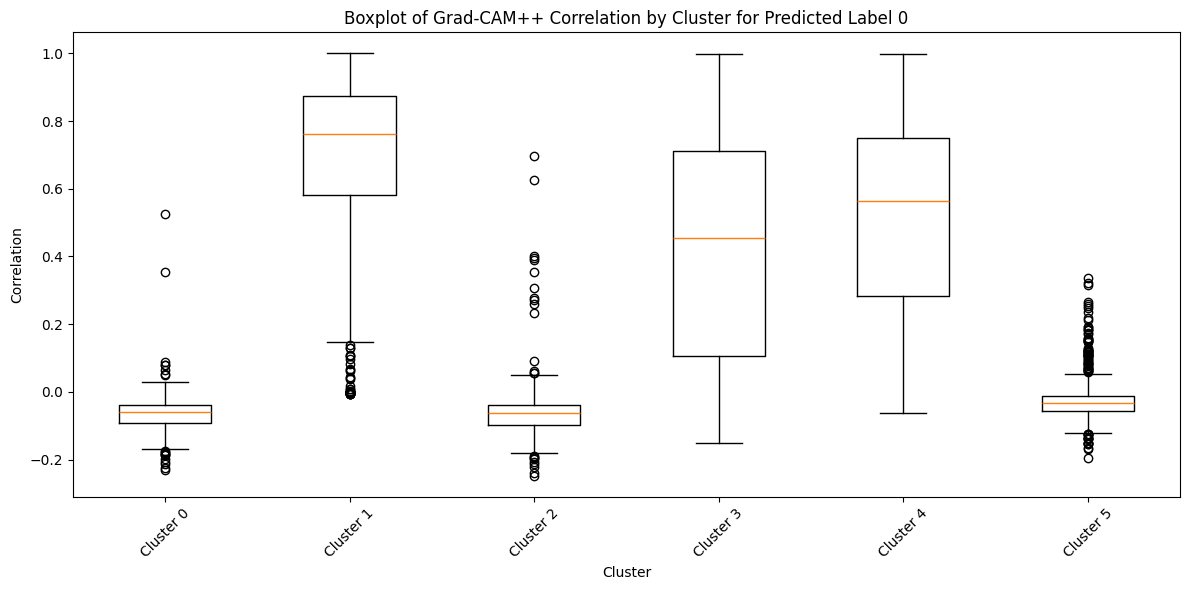

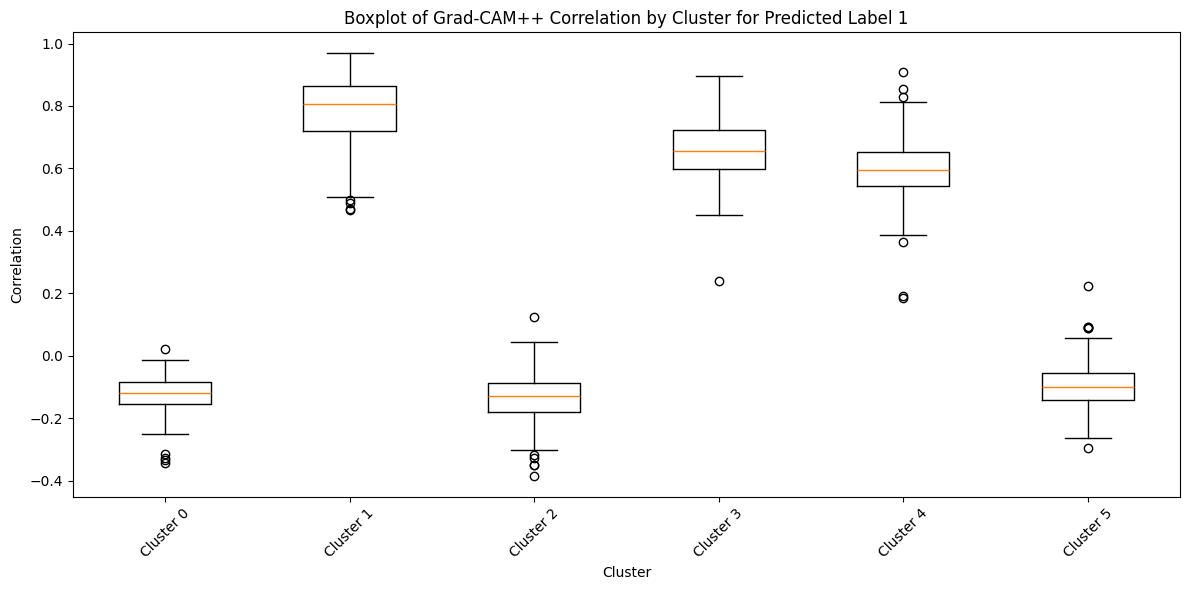

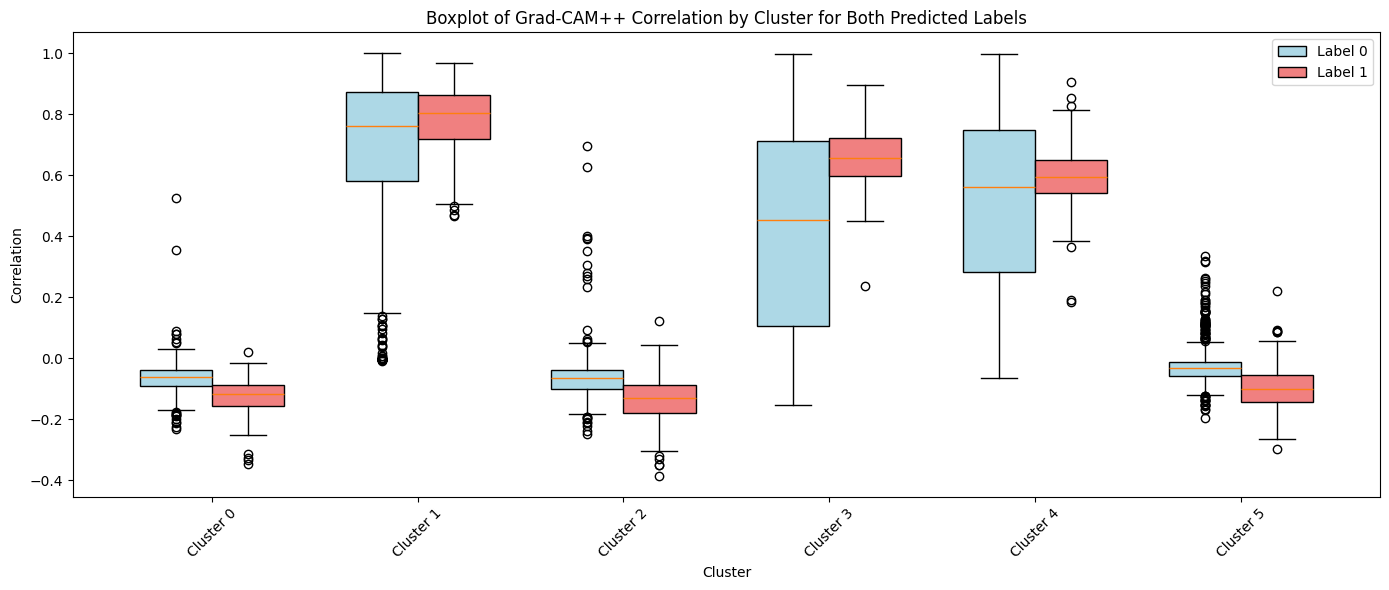

In [ ]:
# filter for grad_cam_pp correlation columns
correlation_cols = [f"correlation_grad_cam_pp_{i}" for i in range(NUM_CLUSTERS)]

# Create two figures: one for label 0, one for label 1
for label_value in [0, 1]:
    plt.figure(figsize=(12, 6))

    # Collect data for all clusters for this label
    cluster_data = []
    cluster_labels = []

    for i, correlation_col in enumerate(correlation_cols):
        # Get correlation values (may contain NaN)
        correlation_data = data[data["predicted_label"] == label_value][
            correlation_col
        ].dropna()
        cluster_data.append(correlation_data)
        cluster_labels.append(f"Cluster {i}")

    # Create boxplot with all clusters side by side
    plt.boxplot(cluster_data, tick_labels=cluster_labels)
    plt.title(
        f"Boxplot of Grad-CAM++ Correlation by Cluster for Predicted Label {label_value}"
    )
    plt.xlabel("Cluster")
    plt.ylabel("Correlation")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Create a figure with both labels together
plt.figure(figsize=(14, 6))

# Collect data for all clusters for both labels
cluster_data_label0 = []
cluster_data_label1 = []
cluster_labels = []

for i, correlation_col in enumerate(correlation_cols):
    # Get data for label 0
    correlation_data_0 = data[data["predicted_label"] == 0][correlation_col].dropna()
    cluster_data_label0.append(correlation_data_0)

    # Get data for label 1
    correlation_data_1 = data[data["predicted_label"] == 1][correlation_col].dropna()
    cluster_data_label1.append(correlation_data_1)

    cluster_labels.append(f"Cluster {i}")

# Create positions for grouped boxplots
positions = np.arange(len(cluster_labels))
width = 0.35

# Create boxplots for both labels
bp0 = plt.boxplot(
    cluster_data_label0,
    positions=positions - width / 2,
    widths=width,
    tick_labels=cluster_labels,
    patch_artist=True,
)
bp1 = plt.boxplot(
    cluster_data_label1,
    positions=positions + width / 2,
    widths=width,
    patch_artist=True,
)

# Color the boxes differently
for patch in bp0["boxes"]:
    patch.set_facecolor("lightblue")
for patch in bp1["boxes"]:
    patch.set_facecolor("lightcoral")

plt.title("Boxplot of Grad-CAM++ Correlation by Cluster for Both Predicted Labels")
plt.xlabel("Cluster")
plt.ylabel("Correlation")
plt.xticks(positions, cluster_labels, rotation=45)
plt.legend([bp0["boxes"][0], bp1["boxes"][0]], ["Label 0", "Label 1"])
plt.tight_layout()
plt.show()

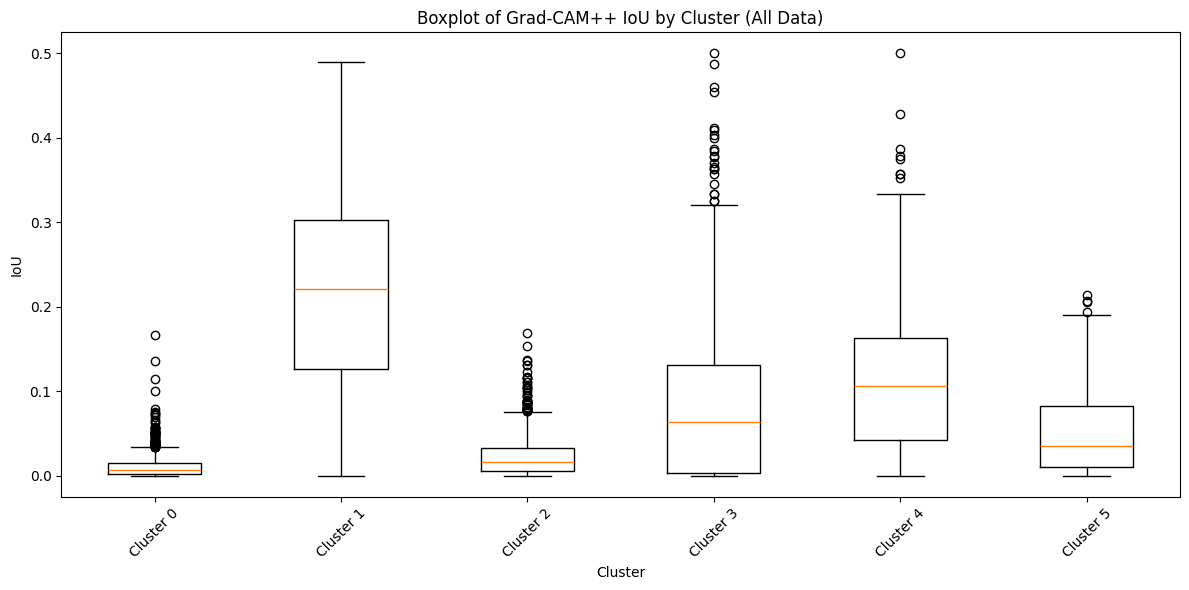

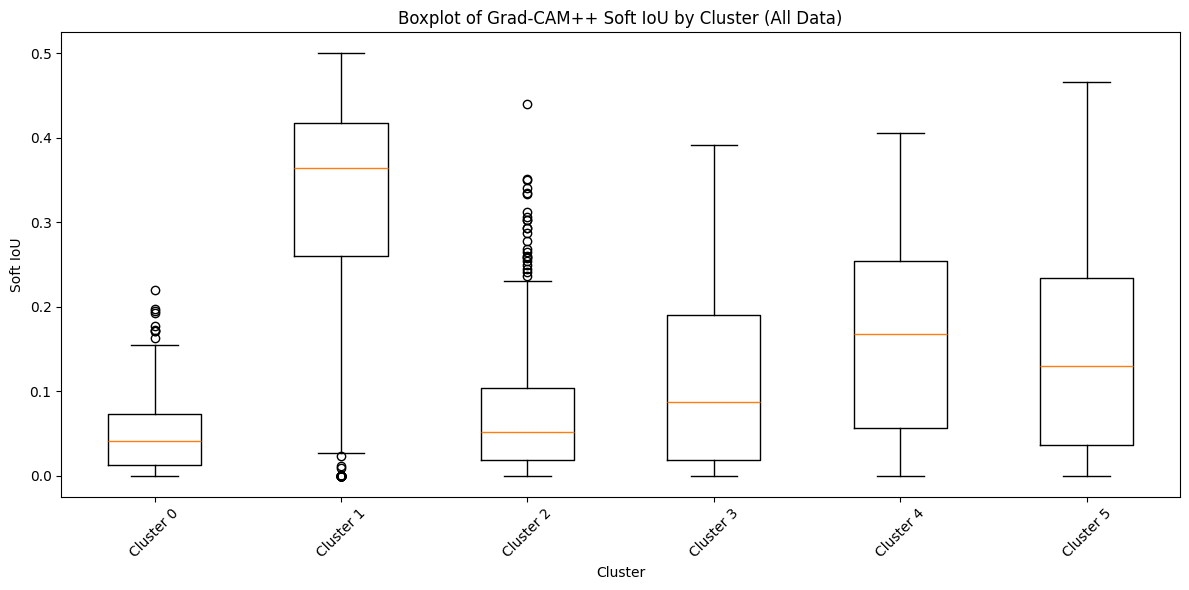

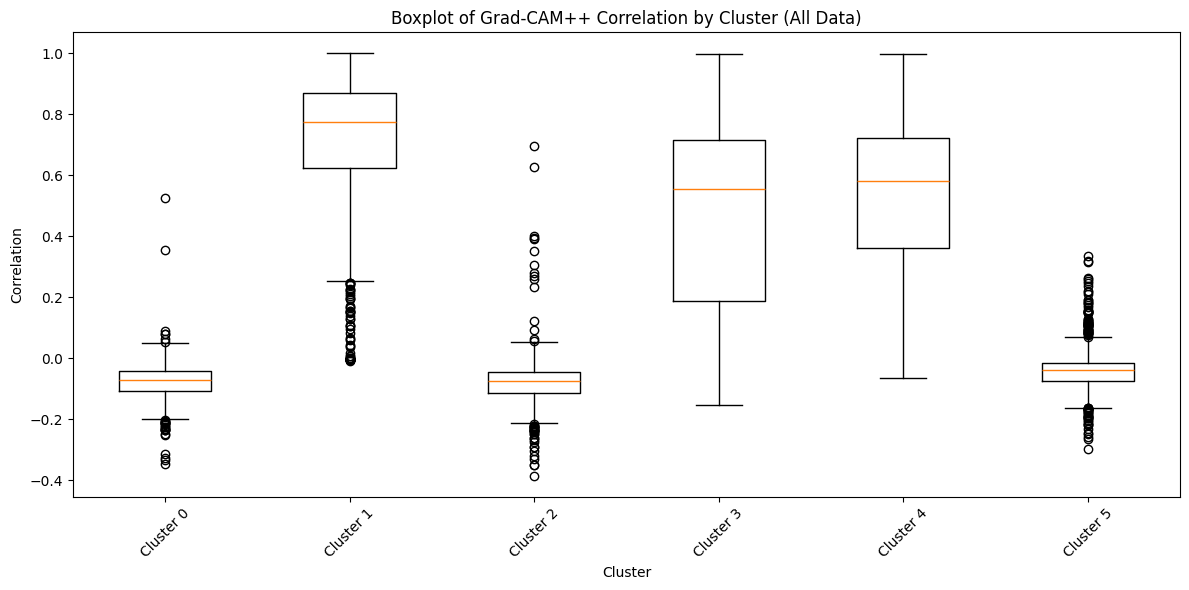

In [ ]:
# Create plots without aggregating by predicted label - all data together

# 1. IoU plot
iou_cols = [f"iou_grad_cam_pp_{i}" for i in range(NUM_CLUSTERS)]
plt.figure(figsize=(12, 6))
cluster_data = []
cluster_labels = []

for i, iou_col in enumerate(iou_cols):
    iou_data = data[iou_col].dropna()
    cluster_data.append(iou_data)
    cluster_labels.append(f"Cluster {i}")

plt.boxplot(cluster_data, tick_labels=cluster_labels)
plt.title("Boxplot of Grad-CAM++ IoU by Cluster (All Data)")
plt.xlabel("Cluster")
plt.ylabel("IoU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Soft IoU plot
soft_iou_cols = [f"iou_soft_grad_cam_pp_{i}" for i in range(NUM_CLUSTERS)]
plt.figure(figsize=(12, 6))
cluster_data = []
cluster_labels = []

for i, iou_col in enumerate(soft_iou_cols):
    iou_data = data[iou_col].dropna()
    cluster_data.append(iou_data)
    cluster_labels.append(f"Cluster {i}")

plt.boxplot(cluster_data, tick_labels=cluster_labels)
plt.title("Boxplot of Grad-CAM++ Soft IoU by Cluster (All Data)")
plt.xlabel("Cluster")
plt.ylabel("Soft IoU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Correlation plot
correlation_cols = [f"correlation_grad_cam_pp_{i}" for i in range(NUM_CLUSTERS)]
plt.figure(figsize=(12, 6))
cluster_data = []
cluster_labels = []

for i, correlation_col in enumerate(correlation_cols):
    correlation_data = data[correlation_col].dropna()
    cluster_data.append(correlation_data)
    cluster_labels.append(f"Cluster {i}")

plt.boxplot(cluster_data, tick_labels=cluster_labels)
plt.title("Boxplot of Grad-CAM++ Correlation by Cluster (All Data)")
plt.xlabel("Cluster")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()